<a href="https://colab.research.google.com/github/Shantanu115/Speech-recognition/blob/main/asr_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vaahan.ai ASR assignment
Deepgram Nova-2 (baseline) | Whisper Medium | IndicWhisper | Sarvam AI  
Metrics: WER, CER, Entity Hit Rate, Fuzzy Score, Latency  
Data: 20 self-recorded Bangalore locality utterances + FLEURS Hindi (30 samples, 50% noise-augmented)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q deepgram-sdk==3.* openai-whisper transformers datasets \
    jiwer rapidfuzz audiomentations soundfile librosa indic-transliteration \
    matplotlib seaborn requests tqdm

In [ ]:
import os, time, warnings, unicodedata, tempfile, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
import librosa
import requests
from tqdm import tqdm
from jiwer import wer, cer
from rapidfuzz import fuzz
from indic_transliteration import sanscript
from indic_transliteration.sanscript import transliterate
from google.colab import userdata

warnings.filterwarnings('ignore')

DEEPGRAM_KEY   = userdata.get('DEEPGRAM_API_KEY')
SARVAM_KEY     = userdata.get('SARVAM_API_KEY')
RECORDINGS_DIR = '/content/drive/MyDrive/asr'
GROUND_TRUTH   = '/content/drive/MyDrive/asr/ground_truth.csv'
TEMP_DIR       = '/tmp/asr_eval'
os.makedirs(TEMP_DIR, exist_ok=True)


In [ ]:
gt = pd.read_csv(GROUND_TRUTH)
gt['filename']     = gt['filename'].str.strip()
gt['ground_truth'] = gt['ground_truth'].str.strip().str.lower()
gt['locality']     = gt['locality'].str.strip()
print(len(gt), 'samples loaded')
gt.head()


20 samples loaded


,filename,ground_truth,locality
0,Koramangala.mp3,haan bhai main koramangala mein rehta hoon,Koramangala
1,Indiranagar.mp3,mera ghar indiranagar ke paas hai 100 feet roa...,Indiranagar
2,Whitefield.mp3,sir main whitefield se hoon thoda door hai,Whitefield
3,Electronic City.mp3,electronic city mein kaam karta hoon phase 2 mein,Electronic City
4,Marathahalli.mp3,arey marathahalli toh bohot far hai yaar,Marathahalli


In [ ]:
FUZZY_THRESHOLD = 75

def _has_devanagari(text):
    return any('DEVANAGARI' in unicodedata.name(c, '') for c in text if c.strip())

def _normalize_word(w):
    if _has_devanagari(w):
        return transliterate(w, sanscript.DEVANAGARI, sanscript.ITRANS).lower()
    return w.lower()

def normalize(text):
    # Word-level ITRANS transliteration to handle mixed-script Hinglish output
    return ' '.join(_normalize_word(w) for w in text.strip().split()) if text else ''

def score(ref, locality, raw):
    hyp     = normalize(raw)
    fscore  = fuzz.partial_ratio(locality.lower(), hyp.lower())
    return {
        'hypothesis_raw': raw,
        'hypothesis':     hyp,
        'wer':            _safe_wer(ref, hyp),
        'cer':            _safe_cer(ref, hyp),
        'fuzzy_score':    fscore,
        'entity_hit':     int(fscore >= FUZZY_THRESHOLD),
    }

def _safe_wer(ref, hyp):
    try:    return wer(ref, hyp)
    except: return 1.0

def _safe_cer(ref, hyp):
    try:    return cer(ref, hyp)
    except: return 1.0

def audio_path(filename):
    return os.path.join(RECORDINGS_DIR, filename)

def load_audio(path, sr=16000):
    return librosa.load(path, sr=sr, mono=True)

def to_wav(audio, sr=16000):
    tmp = tempfile.NamedTemporaryFile(suffix='.wav', delete=False)
    sf.write(tmp.name, audio, sr)
    return tmp.name

def cleanup(path):
    if path and os.path.exists(path):
        os.unlink(path)


## 1. Deepgram Nova-2 (Baseline)

In [ ]:
from deepgram import DeepgramClient, PrerecordedOptions

def run_deepgram(df, api_key, base_dir=None):
    client  = DeepgramClient(api_key)
    opts    = PrerecordedOptions(model='nova-2', language='hi', smart_format=True)
    results = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Deepgram'):
        path = os.path.join(base_dir or RECORDINGS_DIR, row['filename'])
        tmp  = None
        try:
            audio, sr = load_audio(path)
            tmp = to_wav(audio, sr)
            with open(tmp, 'rb') as f:
                t0  = time.time()
                res = client.listen.rest.v('1').transcribe_file({'buffer': f.read()}, opts)
                lat = time.time() - t0
            raw = res.results.channels[0].alternatives[0].transcript
        except Exception as e:
            print(f'  [{row["filename"]}] {e}')
            raw, lat = '', None
        finally:
            cleanup(tmp)
        results.append({'filename': row['filename'], 'locality': row['locality'],
                        'ground_truth': row['ground_truth'], 'latency_s': lat,
                        'model': 'Deepgram Nova-2', **score(row['ground_truth'], row['locality'], raw)})
    return pd.DataFrame(results)

deepgram_df = run_deepgram(gt, DEEPGRAM_KEY)
print(f"WER {deepgram_df['wer'].mean():.3f}  CER {deepgram_df['cer'].mean():.3f}  "
      f"Fuzzy {deepgram_df['fuzzy_score'].mean():.1f}  EHR {deepgram_df['entity_hit'].mean():.1%}  "
      f"Latency {deepgram_df['latency_s'].mean():.2f}s")
deepgram_df[['locality','ground_truth','hypothesis_raw','hypothesis','wer','fuzzy_score','entity_hit']]


Deepgram: 100%|██████████| 20/20 [00:14<00:00,  1.39it/s]

WER 0.831  CER 0.399  Fuzzy 69.5  EHR 55.0%  Latency 0.46s


,locality,ground_truth,hypothesis_raw,hypothesis,wer,fuzzy_score,entity_hit
0,Koramangala,haan bhai main koramangala mein rehta hoon,"हां भाई, मैं कुरमंगला में रहता हूं.","ham bhai, maim kuramamgala mem rahata hum.",1.000000,81.818182,1
1,Indiranagar,mera ghar indiranagar ke paas hai 100 feet roa...,,,1.000000,0.000000,0
2,Whitefield,sir main whitefield se hoon thoda door hai,Sir मैं wife field से हूं. थोड़ा दूध है.,sir maim wife field se hum. tho.da dudha hai.,0.875000,80.000000,1
3,Electronic City,electronic city mein kaam karta hoon phase 2 mein,Electricity में काम करता हूं phase 2 में.,electricity mem kama karata hum phase 2 mem.,0.777778,84.615385,1
4,Marathahalli,arey marathahalli toh bohot far hai yaar,अरे मारा थाली तो बहुत far है यार.,are mara thali to bahuta far hai yara.,0.857143,75.000000,1
5,Jayanagar,main jayanagar 4th block mein rehta hoon,मैं जयनगर fourth block में रहता हूं.,maim jayanagara fourth block mem rahata hum.,0.857143,100.000000,1
6,Rajajinagar,haan rajajinagar wahan se hoon main,"हां, नगर. वहां से हूं मैं.","ham, nagara. vaham se hum maim.",0.833333,57.142857,0
7,Hebbal,hebbal flyover ke paas mera ghar hai,यह बाल fiber के पास मिला करते हैं.,yaha bala fiber ke pasa mila karate haim.,1.000000,66.666667,0
8,Yelahanka,main yelahanka new town mein shift hua hoon re...,मैं यह लहंका new town में shift हूं recently.,maim yaha lahamka new town mem shift hum recen...,0.777778,66.666667,0
9,HSR Layout,hsr layout sector 2 mein rehta hoon,पीछे साथ लिया और sector 2 में रहता हूं मैं,piche satha liya aura sector 2 mem rahata hum ...,1.142857,50.000000,0


## 2. Whisper Medium

In [ ]:
import whisper

whisper_model = whisper.load_model('medium')

def run_whisper(df, model, label='Whisper Medium', base_dir=None):
    results = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=label):
        path = os.path.join(base_dir or RECORDINGS_DIR, row['filename'])
        try:
            t0  = time.time()
            out = model.transcribe(path, language='hi', fp16=True)
            lat = time.time() - t0
            raw = out['text']
        except Exception as e:
            print(f'  [{row["filename"]}] {e}')
            raw, lat = '', None
        results.append({'filename': row['filename'], 'locality': row['locality'],
                        'ground_truth': row['ground_truth'], 'latency_s': lat,
                        'model': label, **score(row['ground_truth'], row['locality'], raw)})
    return pd.DataFrame(results)

whisper_df = run_whisper(gt, whisper_model)
print(f"WER {whisper_df['wer'].mean():.3f}  CER {whisper_df['cer'].mean():.3f}  "
      f"Fuzzy {whisper_df['fuzzy_score'].mean():.1f}  EHR {whisper_df['entity_hit'].mean():.1%}  "
      f"Latency {whisper_df['latency_s'].mean():.2f}s")
whisper_df[['locality','ground_truth','hypothesis_raw','hypothesis','wer','fuzzy_score','entity_hit']]


Whisper Medium: 100%|██████████| 20/20 [00:32<00:00,  1.64s/it]

WER 0.861  CER 0.410  Fuzzy 77.1  EHR 60.0%  Latency 1.64s


,locality,ground_truth,hypothesis_raw,hypothesis,wer,fuzzy_score,entity_hit
0,Koramangala,haan bhai main koramangala mein rehta hoon,हा बही मैं कुर्मंग्रा में रहा हूँ,ha bahi maim kurmamgra mem raha hu.n,1.000000,54.545455,0
1,Indiranagar,mera ghar indiranagar ke paas hai 100 feet roa...,मेरा गर इंजरानगर के पाज से सौफिट रोड के उपर,mera gara imjaranagara ke paja se sauphita rod...,0.727273,72.727273,0
2,Whitefield,sir main whitefield se hoon thoda door hai,सदमा वाय फेल से हूं थोले दो रहे हैं,sadama vaya phela se hum thole do rahe haim,1.000000,35.294118,0
3,Electronic City,electronic city mein kaam karta hoon phase 2 mein,एलेक्टॉरिज़िटिय में काम परता हूं फेज टू में,elektaॉrizitiya mem kama parata hum pheja tu mem,1.000000,62.068966,0
4,Marathahalli,arey marathahalli toh bohot far hai yaar,अरे मारा थली तो बोट फार है यार,are mara thali to bota phara hai yara,1.000000,75.000000,1
5,Jayanagar,main jayanagar 4th block mein rehta hoon,मैं जैनगर फौर्त ब्लॉफ में रहता हूं,maim jainagara phaurta blaॉpha mem rahata hum,1.000000,77.777778,1
6,Rajajinagar,haan rajajinagar wahan se hoon main,हा रारालीनगर वहां से मुइं,ha raralinagara vaham se muim,0.833333,81.818182,1
7,Hebbal,hebbal flyover ke paas mera ghar hai,एब भाल्था यवर्के पास्मी राज वर्के हैं।,eba bhaltha yavarke pasmi raja varke haim|,1.000000,66.666667,0
8,Yelahanka,main yelahanka new town mein shift hua hoon re...,मैं येलहंका नूर टान में शिफ्ट हूँ हूँ रीसेंगलीं।,maim yelahamka nura tana mem shiphta hu.n hu.n...,1.000000,88.888889,1
9,HSR Layout,hsr layout sector 2 mein rehta hoon,H.S.S.S.R.B layout sector 2 में रहता हूँ नहीं।,h.s.s.s.r.b layout sector 2 mem rahata hu.n na...,0.714286,80.000000,1


## 3. IndicWhisper (Hindi fine-tuned)

In [ ]:
from transformers import pipeline as hf_pipeline
import torch

device     = 0 if torch.cuda.is_available() else -1
dtype      = torch.float16 if device == 0 else torch.float32
indic_pipe = hf_pipeline('automatic-speech-recognition',
                          model='vasista22/whisper-hindi-large-v2',
                          device=device, dtype=dtype, chunk_length_s=30)

def run_indicwhisper(df, pipe, label='IndicWhisper', base_dir=None):
    results = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=label):
        path = os.path.join(base_dir or RECORDINGS_DIR, row['filename'])
        try:
            audio, sr = load_audio(path)
            t0  = time.time()
            out = pipe({'array': audio, 'sampling_rate': sr})
            lat = time.time() - t0
            raw = out['text']
        except Exception as e:
            print(f'  [{row["filename"]}] {e}')
            raw, lat = '', None
        results.append({'filename': row['filename'], 'locality': row['locality'],
                        'ground_truth': row['ground_truth'], 'latency_s': lat,
                        'model': label, **score(row['ground_truth'], row['locality'], raw)})
    return pd.DataFrame(results)

indic_df = run_indicwhisper(gt, indic_pipe)
print(f"WER {indic_df['wer'].mean():.3f}  CER {indic_df['cer'].mean():.3f}  "
      f"Fuzzy {indic_df['fuzzy_score'].mean():.1f}  EHR {indic_df['entity_hit'].mean():.1%}  "
      f"Latency {indic_df['latency_s'].mean():.2f}s")
indic_df[['locality','ground_truth','hypothesis_raw','hypothesis','wer','fuzzy_score','entity_hit']]


Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).
IndicWhisper:   0%|          | 0/20 [00:00<?, ?it/s]A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.gen

WER 0.910  CER 0.776  Fuzzy 74.2  EHR 55.0%  Latency 13.10s


,locality,ground_truth,hypothesis_raw,hypothesis,wer,fuzzy_score,entity_hit
0,Koramangala,haan bhai main koramangala mein rehta hoon,"हाँ भाई, मैं कुड़मंगला में रहता हूँ।","ha.n bhai, maim ku.damamgala mem rahata hu.n|",1.000000,63.636364,0
1,Indiranagar,mera ghar indiranagar ke paas hai 100 feet roa...,"मेरा घर इंदिरानगर के पास है, सॉफ्टफिट रोड के ऊपर.","mera ghara imdiranagara ke pasa hai, saॉphtaph...",0.727273,90.909091,1
2,Whitefield,sir main whitefield se hoon thoda door hai,"जब मैं व्हाइट फील्ड से हूँ, थोड़ा दूध है।","jaba maim vhaita philda se hu.n, tho.da dudha ...",1.000000,50.000000,0
3,Electronic City,electronic city mein kaam karta hoon phase 2 mein,इलेक्ट्रॉनिक सिटी में काम करता हूँ (फ़ेज2) में.,ilektraॉnika siti mem kama karata hu.n (feja2)...,1.000000,60.000000,0
4,Marathahalli,arey marathahalli toh bohot far hai yaar,अरे माराथली तो बहुत सहार है यार.,are marathali to bahuta sahara hai yara.,0.857143,75.000000,1
5,Jayanagar,main jayanagar 4th block mein rehta hoon,मैं जयनगर फोर्ट ब्लॉक में रहता हूँ।,maim jayanagara phorta blaॉka mem rahata hu.n|,1.000000,100.000000,1
6,Rajajinagar,haan rajajinagar wahan se hoon main,"हाँ, राजनगर, वहाँ से हुए.","ha.n, rajanagara, vaha.n se hue.",0.833333,81.818182,1
7,Hebbal,hebbal flyover ke paas mera ghar hai,एब्बाल फ्लाइबर के पास मेरा घर है।,ebbala phlaibara ke pasa mera ghara hai|,0.714286,90.909091,1
8,Yelahanka,main yelahanka new town mein shift hua hoon re...,मैं यह लहंका न्यू टाउन में शिफ्ट हुआ हूँ रीसें...,maim yaha lahamka nyu tauna mem shiphta hua hu...,1.000000,66.666667,0
9,HSR Layout,hsr layout sector 2 mein rehta hoon,एचएस सात लेआउट सेक्टर 2 में रहता हूँ मैं.,echaesa sata leauta sektara 2 mem rahata hu.n ...,1.142857,60.000000,0


## 4. Sarvam AI (Saaras v3)

In [ ]:
SARVAM_URL = 'https://api.sarvam.ai/speech-to-text'
import threading
import threading

class RateLimiter:
    """Token bucket — enforces minimum gap between calls."""
    def __init__(self, calls_per_minute=20):
        self._interval = 60.0 / calls_per_minute
        self._last     = 0.0
        self._lock     = threading.Lock()

    def wait(self):
        with self._lock:
            gap = time.time() - self._last
            if gap < self._interval:
                time.sleep(self._interval - gap)
            self._last = time.time()


_sarvam_limiter = RateLimiter(calls_per_minute=15)

def run_sarvam(df, api_key, label='Sarvam AI', base_dir=None):
    headers = {'api-subscription-key': api_key}
    results = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=label):
        path = os.path.join(base_dir or RECORDINGS_DIR, row['filename'])
        tmp  = None
        raw, lat = '', None
        try:
            audio, sr = load_audio(path)
            tmp = to_wav(audio, sr)
            for attempt in range(5):
                _sarvam_limiter.wait()
                with open(tmp, 'rb') as f:
                    files = {'file': (row['filename'].rsplit('.', 1)[0] + '.wav', f, 'audio/wav')}
                    data  = {'language_code': 'hi-IN', 'model': 'saaras:v3'}
                    t0    = time.time()
                    resp  = requests.post(SARVAM_URL, headers=headers,
                                          files=files, data=data, timeout=30)
                    lat   = time.time() - t0
                if resp.status_code == 429:
                    wait = min(30, 2 ** attempt)
                    print(f'  [{row["filename"]}] 429, retry {attempt+1}/5 in {wait}s')
                    lat = None
                    time.sleep(wait)
                    continue
                resp.raise_for_status()
                raw = resp.json().get('transcript', '')
                break
        except Exception as e:
            print(f'  [{row["filename"]}] {e}')
        finally:
            cleanup(tmp)
        results.append({'filename': row['filename'], 'locality': row['locality'],
                        'ground_truth': row['ground_truth'], 'latency_s': lat,
                        'model': label, **score(row['ground_truth'], row['locality'], raw)})
    return pd.DataFrame(results)




sarvam_df = run_sarvam(gt, SARVAM_KEY)
print(f"WER {sarvam_df['wer'].mean():.3f}  CER {sarvam_df['cer'].mean():.3f}  "
      f"Fuzzy {sarvam_df['fuzzy_score'].mean():.1f}  EHR {sarvam_df['entity_hit'].mean():.1%}  "
      f"Latency {sarvam_df['latency_s'].mean():.2f}s")
sarvam_df[['locality','ground_truth','hypothesis_raw','hypothesis','wer','fuzzy_score','entity_hit']]


Sarvam AI:  50%|█████     | 10/20 [00:43<00:42,  4.25s/it]

  [BTM layout.mp3] 429, retry 1/5 in 1s


Sarvam AI:  55%|█████▌    | 11/20 [00:51<00:48,  5.39s/it]

  [Silk board.mp3] 429, retry 1/5 in 1s


Sarvam AI:  65%|██████▌   | 13/20 [01:03<00:38,  5.54s/it]

...

Sarvam AI:  95%|█████████▌| 19/20 [01:44<00:06,  6.24s/it]

  [Thanisandra.mp3] 429, retry 1/5 in 1s


Sarvam AI: 100%|██████████| 20/20 [01:51<00:00,  5.58s/it]

WER 0.940  CER 0.417  Fuzzy 77.1  EHR 55.0%  Latency 2.30s


,locality,ground_truth,hypothesis_raw,hypothesis,wer,fuzzy_score,entity_hit
0,Koramangala,haan bhai main koramangala mein rehta hoon,"हाँ भाई, मैं कोरमंगला में रहता हूँ।","ha.n bhai, maim koramamgala mem rahata hu.n|",1.000000,90.909091,1
1,Indiranagar,mera ghar indiranagar ke paas hai 100 feet roa...,"मेरा घर इंदिरानगर के पास है, 100 फीट रोड के ऊपर।","mera ghara imdiranagara ke pasa hai, 100 phita...",0.636364,90.909091,1
2,Whitefield,sir main whitefield se hoon thoda door hai,"सर, मैं वाइट फील्ड से हूँ, थोड़ा दूर है।","sara, maim vaita philda se hu.n, tho.da dura hai|",1.000000,50.000000,0
3,Electronic City,electronic city mein kaam karta hoon phase 2 mein,इलेक्ट्रॉनिक सिटी में काम करता हूँ फेज़ टू में,ilektraॉnika siti mem kama karata hu.n pheza t...,1.000000,60.000000,0
4,Marathahalli,arey marathahalli toh bohot far hai yaar,अरे मारा थाली तो बहुत फार है यार,are mara thali to bahuta phara hai yara,1.000000,75.000000,1
5,Jayanagar,main jayanagar 4th block mein rehta hoon,मैं जयनगर फोर्थ ब्लॉक में रहता हूँ,maim jayanagara phortha blaॉka mem rahata hu.n,1.000000,100.000000,1
6,Rajajinagar,haan rajajinagar wahan se hoon main,"हाँ, राधाजी नगर वहाँ से हूँ मैं।","ha.n, radhaji nagara vaha.n se hu.n maim|",1.000000,72.727273,0
7,Hebbal,hebbal flyover ke paas mera ghar hai,हेब्बाल फ्लाईओवर के पास मेरा घर है।,hebbala phlaiovara ke pasa mera ghara hai|,0.714286,100.000000,1
8,Yelahanka,main yelahanka new town mein shift hua hoon re...,मैं ये लहंगा न्यू टाउन में शिफ्ट हुआ हूँ रिसेंटली,maim ye lahamga nyu tauna mem shiphta hua hu.n...,1.000000,66.666667,0
9,HSR Layout,hsr layout sector 2 mein rehta hoon,नीचे सात लेआउट सेक्टर टू में रहता हूँ मैं।,niche sata leauta sektara tu mem rahata hu.n m...,1.285714,60.000000,0


## 5. FLEURS Hindi — Out-of-domain Evaluation
Google FLEURS `hi_in` test split, 30 samples. 50% augmented with Gaussian noise (seed=42).

In [ ]:
from datasets import load_dataset
from audiomentations import Compose, AddGaussianNoise

random.seed(42)
np.random.seed(42)

augmentor = Compose([AddGaussianNoise(min_amplitude=0.005, max_amplitude=0.04, p=1.0)])

stream = load_dataset('google/fleurs', 'hi_in', split='test', streaming=True)

fleurs_rows = []
for i, s in enumerate(stream):
    if i >= 30:
        break
    audio = librosa.resample(s['audio']['array'].astype(np.float32),
                             orig_sr=s['audio']['sampling_rate'], target_sr=16000)
    noisy = random.random() < 0.5
    if noisy:
        audio = augmentor(samples=audio, sample_rate=16000)

    fname = f"fleurs_{i:02d}_{'noisy' if noisy else 'clean'}.wav"
    sf.write(os.path.join(TEMP_DIR, fname), audio, 16000)
    fleurs_rows.append({
        'filename':     fname,
        'ground_truth': s['transcription'].strip().lower(),
        'locality':     'N/A',
        'noisy':        noisy,
    })

gt_fleurs = pd.DataFrame(fleurs_rows)
print(f"{len(gt_fleurs)} samples — {gt_fleurs['noisy'].sum()} noisy, {(~gt_fleurs['noisy']).sum()} clean")


30 samples — 11 noisy, 19 clean


In [ ]:
fleurs_deepgram_df = run_deepgram(gt_fleurs,     DEEPGRAM_KEY,  base_dir=TEMP_DIR)
fleurs_whisper_df  = run_whisper(gt_fleurs,      whisper_model, base_dir=TEMP_DIR)
fleurs_indic_df    = run_indicwhisper(gt_fleurs, indic_pipe,    base_dir=TEMP_DIR)
fleurs_sarvam_df   = run_sarvam(gt_fleurs,       SARVAM_KEY,    base_dir=TEMP_DIR)

fleurs_all_df = pd.concat(
    [fleurs_deepgram_df, fleurs_whisper_df, fleurs_indic_df, fleurs_sarvam_df],
    ignore_index=True,
)
fleurs_all_df['noisy'] = fleurs_all_df['filename'].str.contains('noisy')

print(f"FLEURS eval done — {len(fleurs_all_df)} rows")


Sarvam AI:  33%|███▎      | 10/30 [00:38<01:22,  4.12s/it]

  [fleurs_10_noisy.wav] 429, retry 1/5 in 1s
  [fleurs_10_noisy.wav] 429, retry 2/5 in 2s
  [fleurs_10_noisy.wav] 429, retry 3/5 in 4s
  [fleurs_10_noisy.wav] 429, retry 4/5 in 8s


Sarvam AI:  73%|███████▎  | 22/30 [02:19<00:39,  4.99s/it]

  [fleurs_22_noisy.wav] 429, retry 1/5 in 1s


Sarvam AI:  77%|███████▋  | 23/30 [02:26<00:40,  5.82s/it]

...

  [fleurs_27_clean.wav] 429, retry 1/5 in 1s


Sarvam AI:  97%|█████████▋| 29/30 [03:15<00:07,  7.26s/it]

  [fleurs_29_clean.wav] 429, retry 1/5 in 1s


Sarvam AI: 100%|██████████| 30/30 [03:22<00:00,  6.76s/it]

FLEURS eval done — 120 rows


## Results

In [ ]:
own_df = pd.concat([deepgram_df, whisper_df, indic_df, sarvam_df], ignore_index=True)

summary = own_df.groupby('model').agg(
    WER=('wer', 'mean'), CER=('cer', 'mean'),
    Fuzzy=('fuzzy_score', 'mean'), EHR=('entity_hit', 'mean'),
    Latency=('latency_s', 'mean')
).round(3).reset_index().sort_values('WER')

summary['EHR'] = summary['EHR'].map('{:.1%}'.format)
print(summary.to_string(index=False))


          model   WER   CER  Fuzzy   EHR  Latency
Deepgram Nova-2 0.831 0.399 69.479 55.0%    0.458
 Whisper Medium 0.861 0.410 77.090 60.0%    1.640
   IndicWhisper 0.910 0.776 74.235 55.0%   13.101
      Sarvam AI 0.940 0.417 77.130 55.0%    2.301


In [ ]:
fleurs_summary = (
    fleurs_all_df.groupby(['model', 'noisy'])['wer']
    .mean().round(3).unstack()
    .rename(columns={False: 'WER_clean', True: 'WER_noisy'})
)
fleurs_summary['degradation'] = (fleurs_summary['WER_noisy'] - fleurs_summary['WER_clean']).round(3)
print(fleurs_summary.to_string())


noisy            WER_clean  WER_noisy  degradation
model                                             
Deepgram Nova-2      1.011      1.041        0.030
IndicWhisper         0.997      1.023        0.026
Sarvam AI            1.007      1.011        0.004
Whisper Medium       1.026      1.032        0.006


## Visualizations

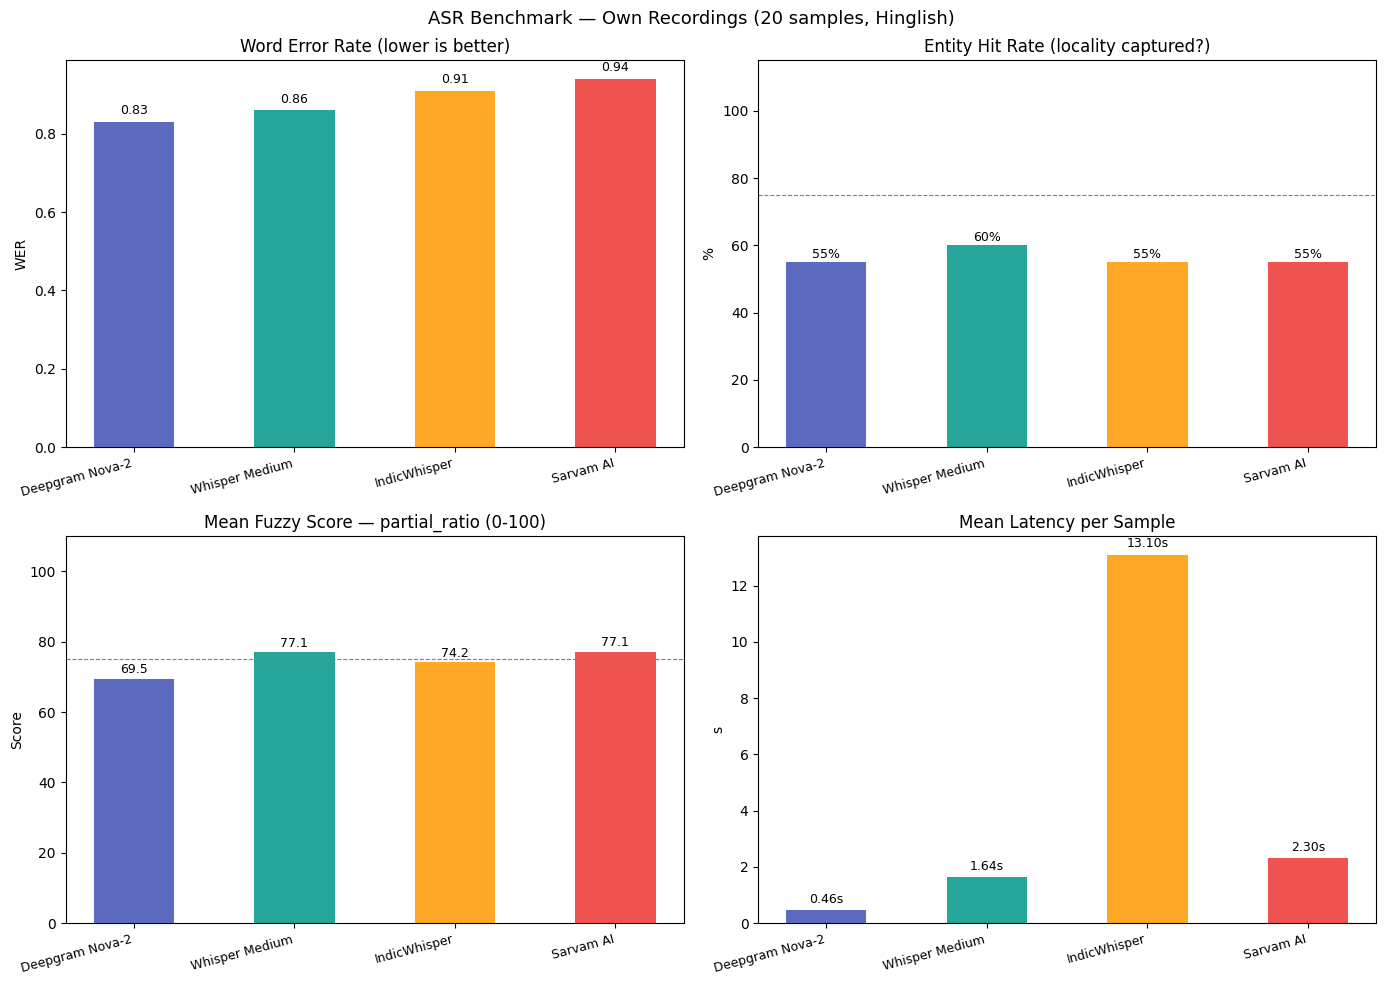

In [ ]:
MODELS  = ['Deepgram Nova-2', 'Whisper Medium', 'IndicWhisper', 'Sarvam AI']
COLORS  = ['#5C6BC0', '#26A69A', '#FFA726', '#EF5350']
cmap    = dict(zip(MODELS, COLORS))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ASR Benchmark — Own Recordings (20 samples, Hinglish)', fontsize=13)

def bar(ax, data, title, ylabel, fmt='{:.2f}', ylim=None):
    bars = ax.bar(data.index, data.values, color=[cmap.get(m, '#999') for m in data.index], width=0.5)
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.set_xticklabels(data.index, rotation=15, ha='right', fontsize=9)
    if ylim: ax.set_ylim(*ylim)
    for b, v in zip(bars, data.values):
        ax.text(b.get_x() + b.get_width()/2, v + max(data.values)*0.02,
                fmt.format(v), ha='center', fontsize=9)

bar(axes[0,0], own_df.groupby('model')['wer'].mean().reindex(MODELS),
    'Word Error Rate (lower is better)', 'WER')

ehr = own_df.groupby('model')['entity_hit'].mean().reindex(MODELS) * 100
bar(axes[0,1], ehr, 'Entity Hit Rate (locality captured?)', '%',
    fmt='{:.0f}%', ylim=(0, 115))
axes[0,1].axhline(y=75, color='gray', linestyle='--', linewidth=0.8, label='75% threshold')

bar(axes[1,0], own_df.groupby('model')['fuzzy_score'].mean().reindex(MODELS),
    'Mean Fuzzy Score — partial_ratio (0-100)', 'Score', fmt='{:.1f}', ylim=(0, 110))
axes[1,0].axhline(y=75, color='gray', linestyle='--', linewidth=0.8)

bar(axes[1,1], own_df.groupby('model')['latency_s'].mean().reindex(MODELS),
    'Mean Latency per Sample', 's', fmt='{:.2f}s')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/asr/benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()


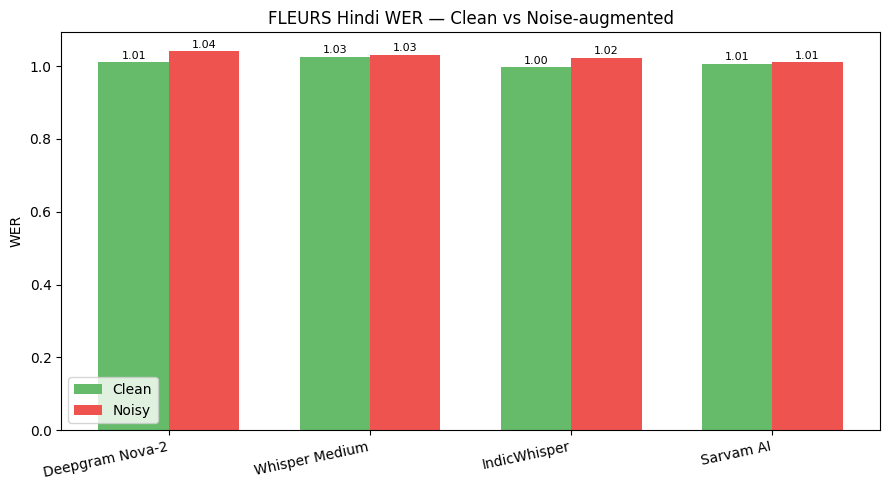

In [ ]:
x     = np.arange(len(MODELS))
w     = 0.35
clean = [fleurs_summary.loc[m, 'WER_clean'] for m in MODELS]
noisy = [fleurs_summary.loc[m, 'WER_noisy'] for m in MODELS]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, clean, w, label='Clean', color='#66BB6A')
ax.bar(x + w/2, noisy, w, label='Noisy', color='#EF5350')
ax.set_title('FLEURS Hindi WER — Clean vs Noise-augmented')
ax.set_ylabel('WER'); ax.set_xticks(x); ax.set_xticklabels(MODELS, rotation=12, ha='right')
ax.legend()
for i, (c, n) in enumerate(zip(clean, noisy)):
    ax.text(i - w/2, c + 0.01, f'{c:.2f}', ha='center', fontsize=8)
    ax.text(i + w/2, n + 0.01, f'{n:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/asr/fleurs_results.png', dpi=150, bbox_inches='tight')
plt.show()


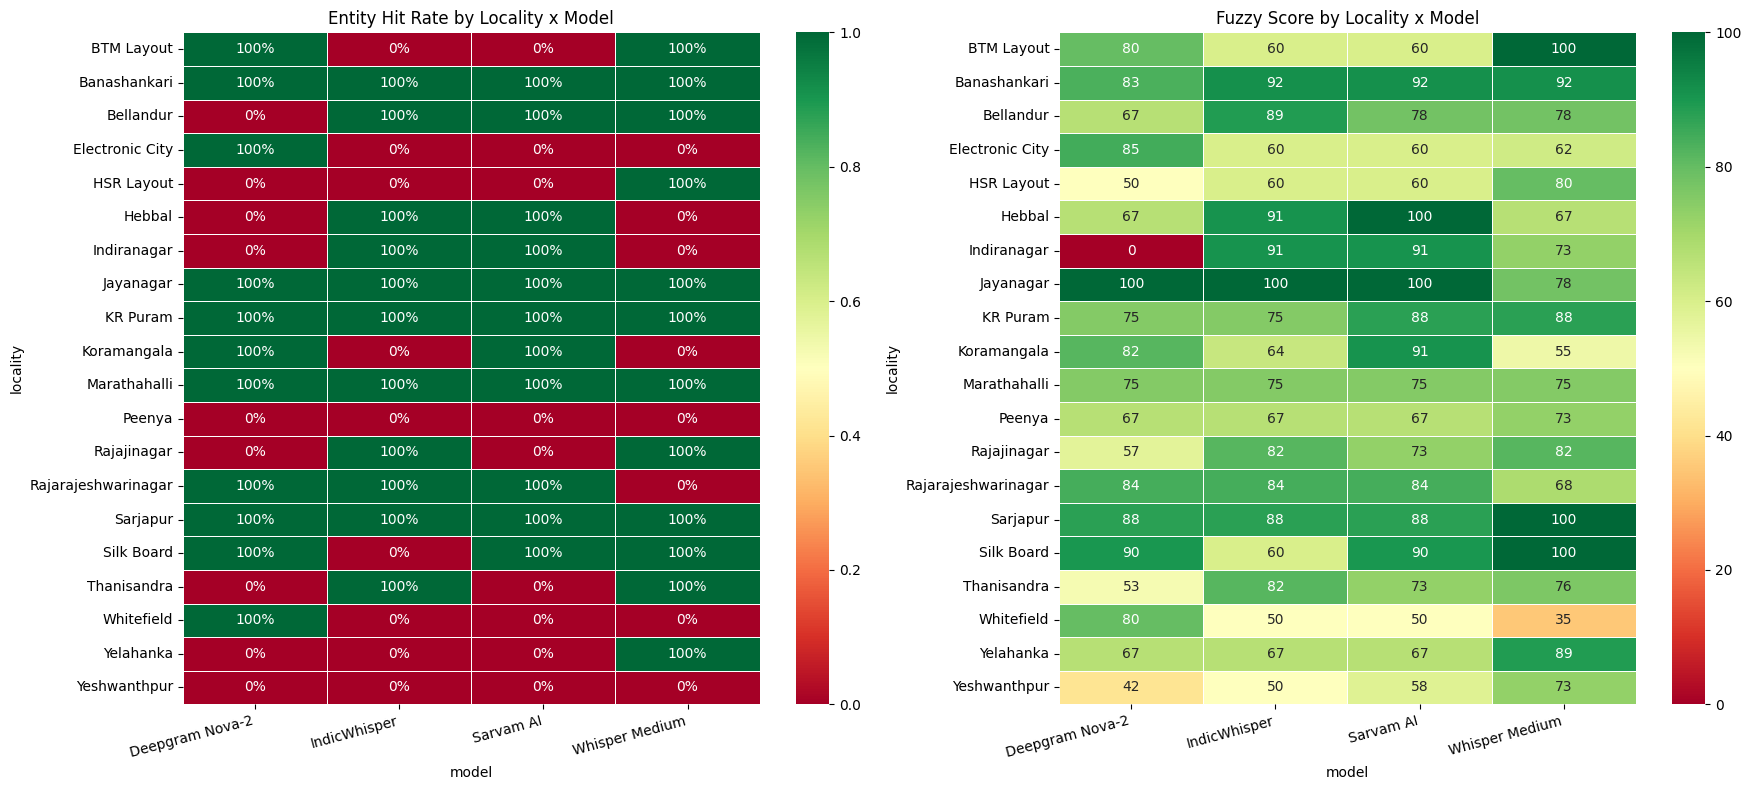

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

pivot_ehr = own_df.pivot_table(index='locality', columns='model',
                                values='entity_hit', aggfunc='mean').fillna(0)
sns.heatmap(pivot_ehr, annot=True, fmt='.0%', cmap='RdYlGn',
            linewidths=0.4, vmin=0, vmax=1, ax=ax1)
ax1.set_title('Entity Hit Rate by Locality x Model')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=15, ha='right')

pivot_fuz = own_df.pivot_table(index='locality', columns='model',
                                values='fuzzy_score', aggfunc='mean').fillna(0)
sns.heatmap(pivot_fuz, annot=True, fmt='.0f', cmap='RdYlGn',
            linewidths=0.4, vmin=0, vmax=100, ax=ax2)
ax2.set_title('Fuzzy Score by Locality x Model')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/asr/heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()


## Failure Analysis

In [ ]:
print('Hardest localities (avg EHR across models):')
print(own_df.groupby('locality')['entity_hit'].mean().sort_values().round(2).to_string())

print('\nConsistently missed (entity_hit=0 in all models):')
miss_counts = own_df.groupby('locality')['entity_hit'].sum()
print(miss_counts[miss_counts == 0].index.tolist())

print('\nWorst individual predictions:')
failures = own_df[own_df['entity_hit'] == 0][
    ['model','locality','hypothesis_raw','fuzzy_score','wer']
].sort_values('fuzzy_score').head(12)
print(failures.to_string(index=False))

print('\nModel consistency (WER std):')
print(own_df.groupby('model')['wer'].agg(['mean','std','min','max']).round(3).to_string())


Hardest localities (avg EHR across models):
locality
Peenya                 0.00
Yeshwanthpur           0.00
HSR Layout             0.25
Electronic City        0.25
Whitefield             0.25
Yelahanka              0.25
Indiranagar            0.50
Hebbal                 0.50
Thanisandra            0.50
Rajajinagar            0.50
Koramangala            0.50
BTM Layout             0.50
Silk Board             0.75
Rajarajeshwarinagar    0.75
Bellandur              0.75
Banashankari           1.00
Sarjapur               1.00
Marathahalli           1.00
KR Puram               1.00
Jayanagar              1.00

Consistently missed (entity_hit=0 in all models):
['Peenya', 'Yeshwanthpur']

Worst individual predictions:
          model     locality                             hypothesis_raw  fuzzy_score      wer
Deepgram Nova-2  Indiranagar                                                0.000000 1.000000
 Whisper Medium   Whitefield        सदमा वाय फेल से हूं थोले दो रहे हैं    35.294118 1.000

In [ ]:
own_df.to_csv('/content/drive/MyDrive/asr/results_own.csv', index=False)
fleurs_all_df.to_csv('/content/drive/MyDrive/asr/results_fleurs.csv', index=False)
print('Saved.')


Saved.
